<a href="https://colab.research.google.com/github/yamatai-wizard/GCI_Competition2/blob/test/NFL_Draft_Prediction_ipynb%E3%80%80%E5%AE%9F%E8%A1%8C%E7%89%88.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第2回データ分析コンペティション：NFL Draft Prediction

## 目次
1. セットアップ
2. データ読み込み
3. データの分析・EDA
4. 前処理
5. ベースラインモデル
6. 仮説と特徴量エンジニアリング
7. 提出ファイル作成
8. 今後の展望

## 1. セットアップ

In [124]:
from google.colab import drive,files
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc

from xgboost import XGBClassifier

!pip install optuna
import optuna
from optuna.samplers import TPESampler

In [126]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 2. データ読み込み

In [127]:
PATH = '/content/drive/MyDrive/GCI/NFL Draft Prediction/'

train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')

## 4. 前処理

In [128]:
# 使わない列の削除
train = train.drop(columns=["Id"])
test = test.drop(columns=["Id"])

In [129]:
def add_missing_indicator_features(df):
  for col in df.columns:
    if df[col].isnull().any():
      df[col + '_missing'] = df[col].isnull().astype(int)
  return df

train = add_missing_indicator_features(train)
test = add_missing_indicator_features(test)

In [130]:
# prompt: [ 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle']に関してこれら+Weight,Heightで回帰予測を作成し欠損値を埋めたい。

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

# 欠損値を埋めたい列
impute_cols = ['Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone','Shuttle']

# 回帰予測に使用する特徴量 (ここでは欠損値を埋めたい列自身と他の数値列を全て使用)
# カテゴリカルデータは除外するか、適切にエンコーディングする必要があります。
numerical_cols = train.select_dtypes(include=np.number).columns.tolist()
# impute_cols に含まれていない数値列も含める
features_for_imputation = [col for col in numerical_cols if col in impute_cols or col not in impute_cols]

# IterativeImputer を使用して欠損値を埋める
# estimator に LinearRegression を指定して回帰予測で埋めます
imputer = IterativeImputer(estimator=LinearRegression(), random_state=42, max_iter=10)

# 訓練データとテストデータを結合して一度に処理する
combined_df = pd.concat([train, test], axis=0)

# 欠損値補完を実行
# 補完対象の列のみを選択してfit_transformを適用し、元のデータフレームに戻す
combined_df[impute_cols] = imputer.fit_transform(combined_df[impute_cols])

# 補完されたデータフレームを元の訓練データとテストデータに分割
train = combined_df[:len(train)]
test = combined_df[len(train):]

print("欠損値補完後のtrainデータの確認:")
print(train[impute_cols].isnull().sum())
print("\n欠損値補完後のtestデータの確認:")
print(test[impute_cols].isnull().sum())


欠損値補完後のtrainデータの確認:
Sprint_40yd         0
Vertical_Jump       0
Bench_Press_Reps    0
Broad_Jump          0
Agility_3cone       0
Shuttle             0
dtype: int64

欠損値補完後のtestデータの確認:
Sprint_40yd         0
Vertical_Jump       0
Bench_Press_Reps    0
Broad_Jump          0
Agility_3cone       0
Shuttle             0
dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [143]:
train.isnull().sum()

,0
Year,0
Age,435
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [144]:
test.isnull().sum()

,0
Year,0
Age,115
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [133]:
# prompt: Positionをラベルエンコーダーして

le = LabelEncoder()
train['Position'] = le.fit_transform(train['Position'])
test['Position'] = le.transform(test['Position'])

/tmp/ipython-input-133-2547046835.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Position'] = le.fit_transform(train['Position'])
/tmp/ipython-input-133-2547046835.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Position'] = le.transform(test['Position'])


In [134]:
# prompt: School列をターゲットエンコーディングしたい。ただし、Position_Typeがkicking_specialistのものとother_specialのものは除いてSchoolごとのDraftedの平均値を出すこと

# kicking_specialist と other_special を除外したデータセットを作成
train_filtered = train[~train['Position_Type'].isin(['kicking_specialist', 'other_special'])]

# SchoolごとのDraftedの平均値を計算
school_target_encoding = train_filtered.groupby('School')['Drafted'].mean()

# 元のデータセットに戻る（フィルタリング解除）
# 計算した平均値を、フィルタリングしていない元のデータセットにマッピングする
# testデータも同様にフィルタリング前のtrainデータで計算した平均値をマッピングする
train['School_encoded'] = train['School'].map(school_target_encoding).fillna(school_target_encoding.mean())
test['School_encoded'] = test['School'].map(school_target_encoding).fillna(school_target_encoding.mean())

# School_encodedがNaNの場合（kicking_specialistやother_specialで、かつそのSchoolがfiltered trainに存在しない場合など）は全体の平均値で補完
# (fillnaで既に補完されているはずだが、念のため確認)
train['School_encoded'].fillna(train_filtered['Drafted'].mean(), inplace=True)
test['School_encoded'].fillna(train_filtered['Drafted'].mean(), inplace=True)

# 元のSchool列は削除 (これは既に前のコードで実行されているが、再度実行しても問題ない)
if 'School' in train.columns:
    train = train.drop(columns=['School'])
if 'School' in test.columns:
    test = test.drop(columns=['School'])

print("新しいSchool_encoded列の確認 (train):")
print(train[['Position_Type', 'School_encoded', 'Drafted']].head())
print("\n新しいSchool_encoded列の確認 (test):")
# 注意: testデータではPosition_Typeはワンホットエンコーディングされているので、Position_Type_kicking_specialistなどの列を確認

新しいSchool_encoded列の確認 (train):
       Position_Type  School_encoded  Drafted
0  offensive_lineman        1.000000      1.0
1    backs_receivers        1.000000      1.0
2    backs_receivers        0.500000      1.0
3  defensive_lineman        0.461538      1.0
4    backs_receivers        0.758621      1.0

新しいSchool_encoded列の確認 (test):


/tmp/ipython-input-134-670195482.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['School_encoded'] = train['School'].map(school_target_encoding).fillna(school_target_encoding.mean())
/tmp/ipython-input-134-670195482.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['School_encoded'] = test['School'].map(school_target_encoding).fillna(school_target_encoding.mean())
/tmp/ipython-input-134-670195482.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through 

In [135]:
# prompt: カテゴリデータをワンホットエンコーディングして.0,1で

import pandas as pd
# カテゴリデータのワンホットエンコーディング
train = pd.get_dummies(train, columns=["Player_Type", "Position_Type"], dummy_na=False, dtype=int)
test = pd.get_dummies(test, columns=["Player_Type", "Position_Type"], dummy_na=False, dtype=int)

# trainとtestでカラムを揃える
train_cols = set(train.columns)
test_cols = set(test.columns)

missing_in_test = list(train_cols - test_cols)
for c in missing_in_test:
    if c != 'Drafted': # 'Drafted' はtestには存在しない
        test[c] = 0.0

missing_in_train = list(test_cols - train_cols)
for c in missing_in_train:
    train[c] = 0.0

# カラムの順序をtrainに合わせる
test = test[train.columns.drop('Drafted')]

In [136]:
train.head()

,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Position,Drafted,Age_missing,Sprint_40yd_missing,Vertical_Jump_missing,Bench_Press_Reps_missing,Broad_Jump_missing,Agility_3cone_missing,Shuttle_missing,School_encoded,Player_Type_defense,Player_Type_offense,Player_Type_special_teams,Position_Type_backs_receivers,Position_Type_defensive_back,Position_Type_defensive_lineman,Position_Type_kicking_specialist,Position_Type_line_backer,Position_Type_offensive_lineman,Position_Type_other_special
0,2011,21.0,1.9050,140.160042,5.39,59.69,29.000000,251.46,7.910000,4.940000,10,1.0,0,0,0,0,0,0,0,1.000000,0,1,0,0,0,0,0,0,1,0
1,2011,24.0,1.8288,87.089735,4.31,101.60,16.000000,332.74,6.692181,4.047337,19,1.0,0,0,0,0,0,1,1,1.000000,0,1,0,1,0,0,0,0,0,0
2,2018,21.0,1.8542,92.986436,4.51,91.44,10.000000,309.88,6.950000,4.370000,19,1.0,0,0,0,0,0,0,0,0.500000,0,1,0,1,0,0,0,0,0,0
3,2010,21.0,1.9304,148.778297,5.09,76.20,39.000000,254.00,8.120000,4.710000,4,1.0,0,0,0,0,0,0,0,0.461538,1,0,0,0,0,1,0,0,0,0
4,2016,21.0,1.8796,92.079251,4.64,78.74,18.450945,281.94,7.130000,4.200000,19,1.0,0,0,0,1,0,0,0,0.758621,0,1,0,1,0,0,0,0,0,0


## 6. 仮説と特徴量エンジニアリング

In [137]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

In [138]:
# import numpy as np
# # School列をターゲットエンコーディング (リーク防止)
# # Cross-validationを用いてターゲットエンコーディングを行う
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# train['School_encoded'] = 0
# for fold, (train_idx, val_idx) in enumerate(kf.split(train.drop('Drafted', axis=1), train['Drafted'])):
#     X_train_fold, X_val_fold = train.iloc[train_idx], train.iloc[val_idx]
#     # 訓練データでのターゲットエンコーディングの平均値を計算
#     school_mean = X_train_fold.groupby('School')['Drafted'].mean()
#     # 検証データに適用
#     train.loc[val_idx, 'School_encoded'] = X_val_fold['School'].map(school_mean).fillna(school_mean.mean())

# # School_encodedが0または1の場合は欠損値にする
# train.loc[train['School_encoded'].isin([0, 1]), 'School_encoded'] = np.nan


# # テストデータに対するターゲットエンコーディング
# # 訓練データ全体の平均値を使用
# school_mean_overall = train.groupby('School')['Drafted'].mean()
# test['School_encoded'] = test['School'].map(school_mean_overall).fillna(school_mean_overall.mean())

# # School_encodedが0または1の場合は欠損値にする
# test.loc[test['School_encoded'].isin([0, 1]), 'School_encoded'] = np.nan

# # 元のSchool列は削除
# train = train.drop(columns=['School'])
# test = test.drop(columns=['School'])

In [139]:
X = train.drop(columns=['Drafted'])
y = train['Drafted']

sampler = TPESampler(seed=42)

# Define objective function specifically for XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }
    model = XGBClassifier(**params, random_state=42,
                          use_label_encoder=False,
                          eval_metric='logloss',
                          verbosity=0)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_valid)[:, 1]
        auc_value = roc_auc_score(y_valid, y_pred_proba)
        auc_scores.append(auc_value)

    return np.mean(auc_scores)

# Optimize only XGBoost
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50, n_jobs=1)

best_params = study.best_params
print(f"XGBoost best params: {best_params}")
print(f"Best AUC: {study.best_value:.4f}\n")

# Build optimized XGBoost model
optimized_model = XGBClassifier(**best_params, random_state=42,
                                use_label_encoder=False,
                                eval_metric='logloss',
                                verbosity=0)

# Evaluate using stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\n=== XGBoost Evaluation ===')
auc_scores = []
test_pred_proba_list = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f'Fold{fold+1}')

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    optimized_model.fit(X_train, y_train)

    y_valid_pred_proba = optimized_model.predict_proba(X_valid)[:,1]
    auc_value = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc_value)
    print(f'AUC:{round(auc_value,4)}')

    test_pred_proba = optimized_model.predict_proba(test)[:,1]
    test_pred_proba_list.append(test_pred_proba)

mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

[I 2025-07-04 05:55:06,190] A new study created in memory with name: no-name-18583948-bda1-42e3-a2c8-ac838d4780b1
[I 2025-07-04 05:55:16,209] Trial 0 finished with value: 0.8340421892885288 and parameters: {'n_estimators': 218, 'max_depth': 15, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'min_child_weight': 1}. Best is trial 0 with value: 0.8340421892885288.
[I 2025-07-04 05:55:21,921] Trial 1 finished with value: 0.8296902609328412 and parameters: {'n_estimators': 440, 'max_depth': 10, 'learning_rate': 0.11114989443094977, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 0.8324426408004217, 'min_child_weight': 3}. Best is trial 0 with value: 0.8340421892885288.
[I 2025-07-04 05:55:22,569] Trial 2 finished with value: 0.8528194202249406 and parameters: {'n_estimators': 132, 'max_depth': 5, 'learning_rate': 0.028145092716060652, 'subsample': 0.762378215816119,

XGBoost best params: {'n_estimators': 258, 'max_depth': 3, 'learning_rate': 0.03610811628974879, 'subsample': 0.6948349709439121, 'colsample_bytree': 0.8843449380234661, 'gamma': 0.36798741193644213, 'min_child_weight': 5}
Best AUC: 0.8561


=== XGBoost Evaluation ===
Fold1
AUC:0.8403
Fold2
AUC:0.8746
Fold3
AUC:0.8694
Fold4
AUC:0.8247
Fold5
AUC:0.8716

Average Validation AUC: 0.8561


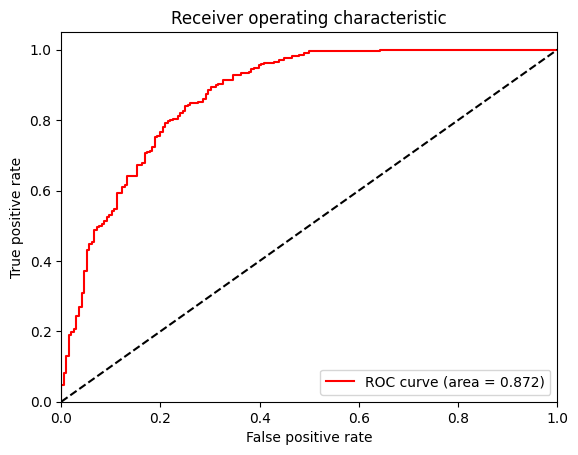

In [140]:
# 偽陽性率と真陽性率の算出
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_pred_proba)

# AUCの算出
auc_value = auc(fpr, tpr)

# ROC曲線の描画
plt.plot(fpr, tpr, color='red', label='ROC curve (area = %.3f)' % auc_value)
plt.plot([0, 1], [0, 1], color='black', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="best")


=== Feature Importances ===
                             Feature  Importance
11                       Age_missing    0.247562
1                                Age    0.210409
21         Player_Type_special_teams    0.056161
18                    School_encoded    0.042199
22     Position_Type_backs_receivers    0.031593
4                        Sprint_40yd    0.030760
29                               BMI    0.027839
3                             Weight    0.027139
6                   Bench_Press_Reps    0.026450
10                          Position    0.026302
9                            Shuttle    0.025026
7                         Broad_Jump    0.024879
2                             Height    0.024872
19               Player_Type_defense    0.024584
8                      Agility_3cone    0.023405
5                      Vertical_Jump    0.020411
12               Sprint_40yd_missing    0.018192
17                   Shuttle_missing    0.016611
16             Agility_3cone_missing    

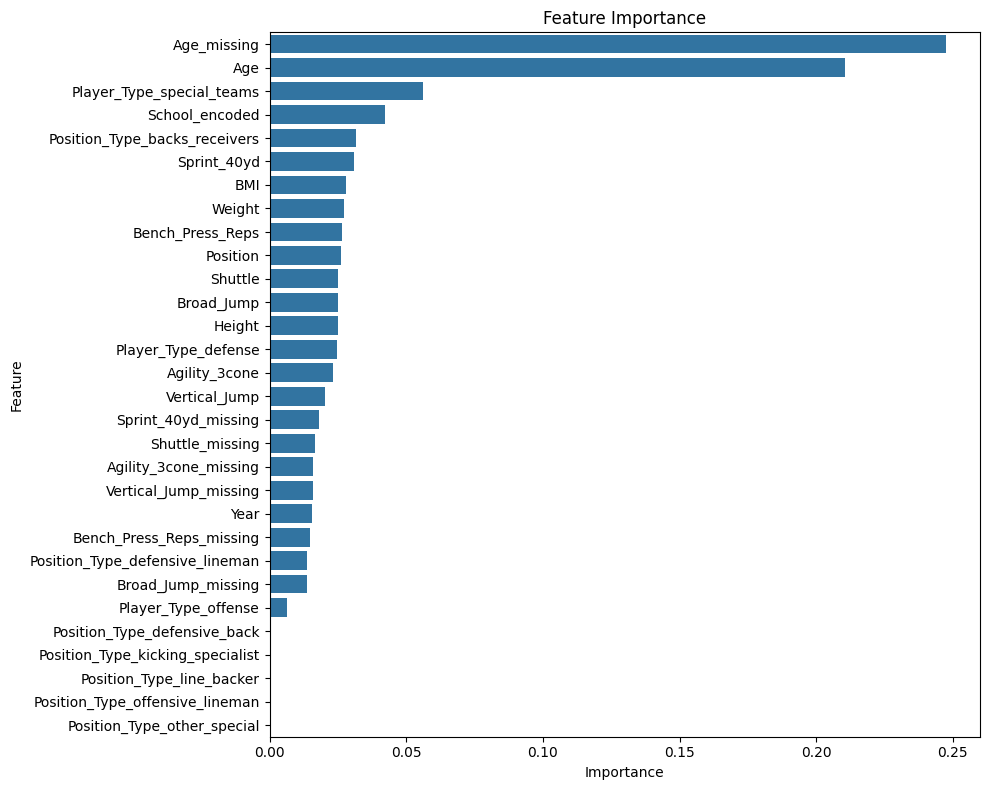

In [141]:
# 特徴量重要度を取得
feature_importances = optimized_model.feature_importances_

# 特徴量名と重要度を組み合わせる
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# 重要度で降順にソート
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 結果を表示
print("\n=== Feature Importances ===")
print(importance_df)

# 特徴量重要度を可視化 (オプション)
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

## 7. 提出ファイル作成

In [142]:
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH + 'submission.csv', index=False)

files.download(PATH + 'submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. 今後の展望

　本ノートブックでは、データの前処理から特徴量エンジニアリング、モデル構築、評価まで、ベースラインモデルの構築を行いました。

　今後はこのベースラインを土台として、さらに高度な特徴量の工夫やアルゴリズムの改善などによって精度向上を目指していくことができます。例えば、以下のような工夫が考えられます。

- カテゴリデータのエンコーディング手法の変更
- 欠損値の補完手法の変更
- 別のモデルの検討
- モデルのハイパーパラメータ調整
- 特徴量エンジニアリング


　高スコア獲得を目指して、頑張りましょう！